# Customer Segmentation using EDA, K-Means, and PCA

This notebook uses the **Mall Customers** dataset to:

1. Conduct simple Exploratory Data Analysis
2. Apply K-Means Clustering to segment customers
3. Use PCA to visualize customer clusters
4. Suggest marketing strategies for each identified segment

The code is kept simple and beginner friendly.

## Step 1: Import required libraries

We use:

- `pandas` and `numpy` for data handling
- `matplotlib` for charts
- `StandardScaler` to scale numeric values
- `KMeans` for clustering
- `PCA` for 2D cluster visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
# Keep Mall_Customers.csv in the same folder as this notebook.
try:
    df = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2: Basic data understanding

Here we check:

- Number of rows and columns
- Column names and data types
- Missing values
- Basic statistical summary

This helps us understand the dataset before applying clustering.

In [2]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

df.describe()

Dataset shape: (200, 5)

Column names:
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Insight

The dataset contains customer information such as age, annual income, and spending score.

For clustering, we will mainly use:

- Age
- Annual Income
- Spending Score

CustomerID is only an identifier, so we do not use it for clustering.

## Step 3: Exploratory Data Analysis

Now we visualize the main variables.

These charts help us understand customer age range, income range, and spending behavior.

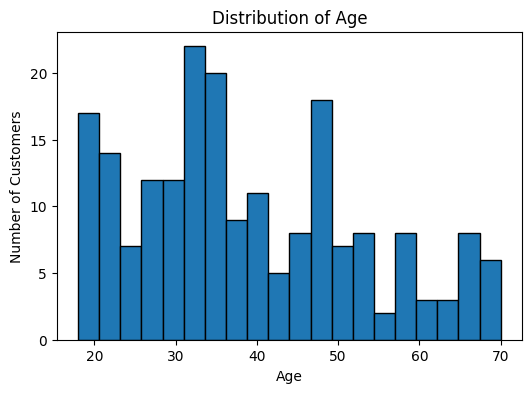

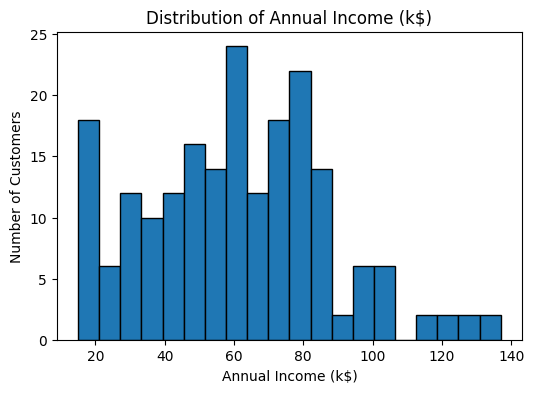

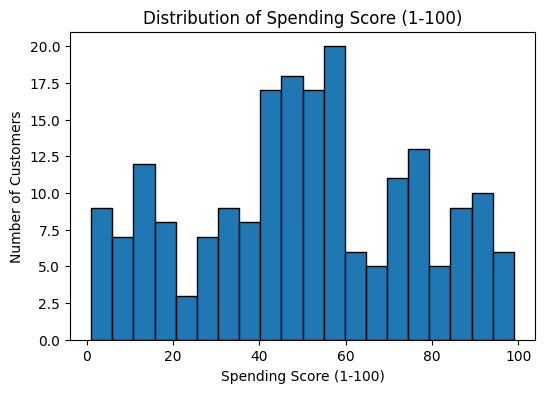

In [3]:
# Histograms for numeric columns
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.show()

### Insight

The histograms show how customers are distributed by age, income, and spending score.

A wide spread in spending score means customers behave differently. This makes the dataset suitable for segmentation.

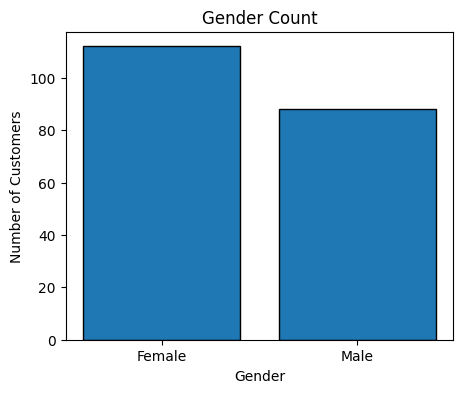

Genre
Female    112
Male       88
Name: count, dtype: int64

In [4]:
# Gender count
gender_count = df["Genre"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(gender_count.index, gender_count.values, edgecolor="black")
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

gender_count

### Insight

This chart shows the gender distribution of customers.

Gender can help in marketing analysis, but for simple clustering we will use numerical features only.

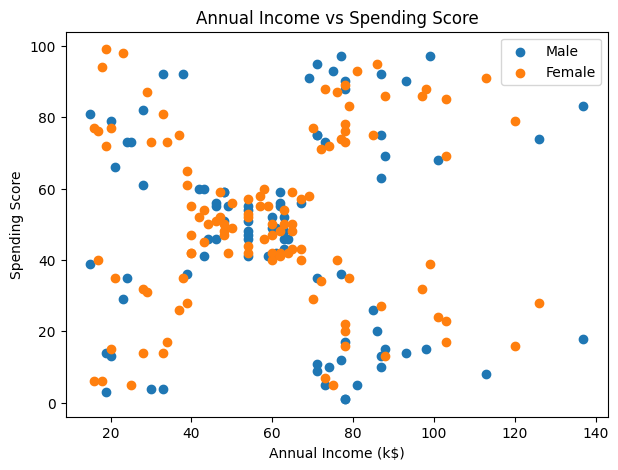

In [5]:
# Relationship between income and spending score
plt.figure(figsize=(7, 5))

for gender in df["Genre"].unique():
    temp = df[df["Genre"] == gender]
    plt.scatter(
        temp["Annual Income (k$)"],
        temp["Spending Score (1-100)"],
        label=gender
    )

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

### Insight

This scatter plot is very useful.

Customers with similar income and spending behavior appear close to each other. K-Means can use this pattern to divide customers into meaningful groups.

## Step 4: Select features for clustering

We select three numerical columns:

- Age
- Annual Income
- Spending Score

These features describe customer profile and buying behavior.

In [6]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Step 5: Scale the data

K-Means uses distance to create clusters.

If one column has larger values than another, it can dominate the clustering. Scaling puts all features on a similar scale.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## Step 6: Find a good number of clusters using the Elbow Method

The Elbow Method helps us decide the value of K.

We test different values of K and calculate inertia. Inertia means how close points are to their cluster centers.

A good K is usually near the point where the curve starts bending.

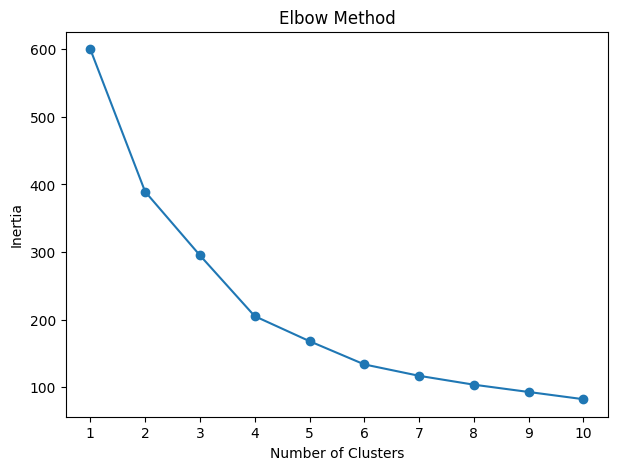

In [8]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(list(K_range))
plt.show()

### Insight

The elbow usually appears around **5 clusters** for this dataset.

So, we will use **K = 5** to segment customers.

## Step 7: Apply K-Means Clustering

Now we create 5 customer segments using K-Means.

Each customer receives a cluster label from 0 to 4.

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [10]:
# Count customers in each cluster
df["Cluster"].value_counts().sort_index()

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

## Step 8: Analyze cluster profiles

We calculate the average age, income, and spending score for each cluster.

This helps us understand what each segment means.

In [11]:
cluster_profile = df.groupby("Cluster")[features].mean().round(1)
cluster_profile["Number of Customers"] = df["Cluster"].value_counts().sort_index()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


### Main cluster insights

Based on the cluster profile, we can describe the segments like this:

- Some customers have low income and low spending.
- Some customers have moderate income and good spending.
- Some customers have high income and high spending.
- Some customers have high income but low spending.
- Some older customers show balanced income and moderate spending.

These differences are useful for creating targeted marketing strategies.

## Step 9: Visualize clusters using PCA

We selected 3 features, so direct visualization is difficult.

PCA converts these 3 features into 2 components so we can plot clusters in a simple 2D chart.

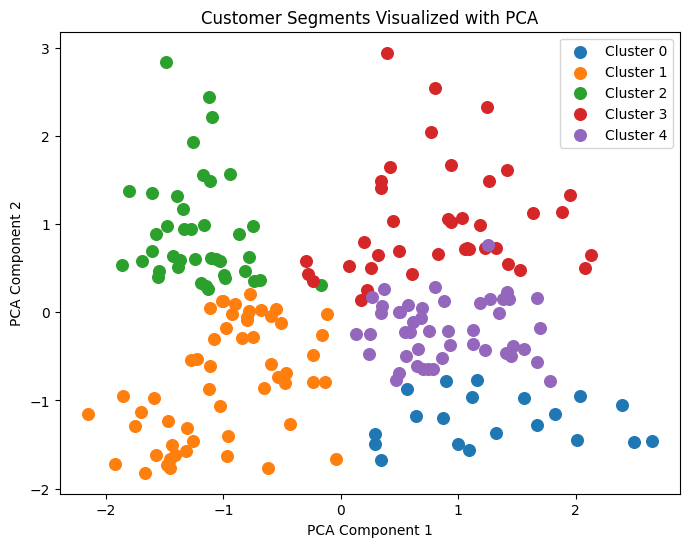

In [12]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(8, 6))

for cluster in sorted(df["Cluster"].unique()):
    temp = df[df["Cluster"] == cluster]
    plt.scatter(temp["PCA1"], temp["PCA2"], label=f"Cluster {cluster}", s=70)

plt.title("Customer Segments Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

### Insight

The PCA chart shows that customers form visible groups.

Clusters that are far apart have different customer behavior. Clusters that are close together may have some similar traits.

## Step 10: Marketing strategies for each segment

Now we suggest simple marketing strategies based on the average profile of each cluster.

The exact cluster number can change if the model is trained again, so always read the cluster profile table before finalizing strategies.

In [13]:
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


### Suggested marketing strategies

**Cluster 0: Older customers with low income and low spending**

Strategy:
- Use budget friendly offers.
- Promote discount days and basic product bundles.
- Avoid luxury focused campaigns for this group.

**Cluster 1: Young customers with moderate income and good spending**

Strategy:
- Target them with trend based products.
- Use social media campaigns, loyalty points, and limited time offers.
- Recommend fashion, lifestyle, and entertainment related products.

**Cluster 2: High income and high spending customers**

Strategy:
- This is a premium customer segment.
- Offer VIP memberships, premium products, early access, and personalized recommendations.
- Focus on quality, exclusivity, and customer experience.

**Cluster 3: High income but low spending customers**

Strategy:
- These customers have buying power but spend less.
- Use personalized offers, product trials, and trust building campaigns.
- Try to understand why they are not spending more.

**Cluster 4: Older customers with average income and moderate spending**

Strategy:
- Offer practical products and value based deals.
- Use membership rewards, family packages, and seasonal promotions.
- Keep communication clear and benefit focused.

## Final conclusion

K-Means clustering helped divide customers into 5 useful segments.

The most valuable segment is usually the group with high income and high spending. The high income but low spending group also has strong potential because targeted marketing may convert them into higher spending customers.

This type of customer segmentation helps businesses improve marketing campaigns, product recommendations, offers, and customer retention.

In [14]:
# Optional: save final dataset with cluster labels
df.to_csv("Mall_Customers_With_Clusters.csv", index=False)

print("Clustered dataset saved as Mall_Customers_With_Clusters.csv")

Clustered dataset saved as Mall_Customers_With_Clusters.csv
